In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA



iris = load_iris()
X = iris.data

n_samples, n_features = X.shape

In [2]:
class GaussianMixtureScratch:

    def __init__(self,
                 n_components=3,
                 max_iter=100,
                 tol=1e-4,  # convergence tolerance
                 random_state=0):

        self.K = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    
    # Initialization
    def initialize(self, X):

        np.random.seed(self.random_state)

        N, D = X.shape

        random_idx = np.random.choice(N, self.K, replace=False) # randomly pick K data points as initial means

        self.means = X[random_idx]  # randomly selected data points as initial means

        self.covariances = np.array(    # initially identical covariance matrix of the entire dataset for each component
            [np.cov(X.T) + 1e-6*np.eye(D) for _ in range(self.K)]
        )

        self.weights = np.ones(self.K) / self.K # initially equal weights for each component

    
    # E-Step
    def expectation(self, X):

        N = X.shape[0]

        responsibilities = np.zeros((N, self.K))    # initialize responsibilities matrix as zeros

        for k in range(self.K):

            responsibilities[:, k] = (
                self.weights[k] *
                multivariate_normal.pdf(
                    X,
                    mean=self.means[k],
                    cov=self.covariances[k],
                    allow_singular=True
                )
            )

        responsibilities /= responsibilities.sum(axis=1, keepdims=True) # normalize responsibilities so that they sum to 1 for each data point, these are posterior probabilities of each data point belonging to each Gaussian component

        return responsibilities

    
    # M-Step
    def maximization(self, X, R):

        N, D = X.shape

        Nk = np.sum(R, axis=0)  # column-wise sum of responsibilities, gives effective number of data points assigned to each component

        self.weights = Nk / N

        self.means = (R.T @ X) / Nk[:, None]    # denominator just change the shape of Nk to be (K, 1) so that broadcasting works correctly, this is the weighted mean of the data points for each component

        self.covariances = []

        for k in range(self.K):

            diff = X - self.means[k]

            cov = np.zeros((D, D))

            for i in range(N):
                cov += R[i, k] * np.outer(diff[i], diff[i])

            cov /= Nk[k]

            cov += 1e-6*np.eye(D)

            self.covariances.append(cov)

        self.covariances = np.array(self.covariances)

    
    # Log Likelihood
    def log_likelihood(self, X):

        likelihood = np.zeros((X.shape[0], self.K))

        for k in range(self.K):

            likelihood[:, k] = (
                self.weights[k] *
                multivariate_normal.pdf(
                    X,
                    mean=self.means[k],
                    cov=self.covariances[k],
                    allow_singular=True
                )
            )

        return np.sum(np.log(np.sum(likelihood, axis=1)))

    
    # Fit
    def fit(self, X):

        self.initialize(X)

        previous_ll = None

        for iteration in range(self.max_iter):

            R = self.expectation(X)

            self.maximization(X, R)

            ll = self.log_likelihood(X)

            print(f"Iteration {iteration+1:3d}   Log-Likelihood = {ll:.4f}")

            if previous_ll is not None:

                if abs(ll - previous_ll) < self.tol:
                    break

            previous_ll = ll

        self.responsibilities = R

    
    # Predict Cluster
    def predict(self, X):

        R = self.expectation(X)

        return np.argmax(R, axis=1) # returns the index of the Gaussian component with the highest responsibility for each data point, effectively assigning each data point to the cluster corresponding to that component

    
    # Probability Density
    def score_samples(self, X):

        likelihood = np.zeros((X.shape[0], self.K))

        for k in range(self.K):

            likelihood[:, k] = (
                self.weights[k] *
                multivariate_normal.pdf(
                    X,
                    mean=self.means[k],
                    cov=self.covariances[k],
                    allow_singular=True
                )
            )

        return np.sum(likelihood, axis=1)

In [3]:
# Train GMM
gmm = GaussianMixtureScratch(
    n_components=3,
    max_iter=100,
    tol=1e-4,
    random_state=42
)

gmm.fit(X)

Iteration   1   Log-Likelihood = -343.2978
Iteration   2   Log-Likelihood = -322.7581
Iteration   3   Log-Likelihood = -294.6562
Iteration   4   Log-Likelihood = -258.3722
Iteration   5   Log-Likelihood = -210.4759
Iteration   6   Log-Likelihood = -206.7394
Iteration   7   Log-Likelihood = -206.4338
Iteration   8   Log-Likelihood = -206.1682
Iteration   9   Log-Likelihood = -205.8312
Iteration  10   Log-Likelihood = -205.2954
Iteration  11   Log-Likelihood = -204.3909
Iteration  12   Log-Likelihood = -202.9489
Iteration  13   Log-Likelihood = -200.7131
Iteration  14   Log-Likelihood = -197.2597
Iteration  15   Log-Likelihood = -192.8784
Iteration  16   Log-Likelihood = -188.4628
Iteration  17   Log-Likelihood = -184.8562
Iteration  18   Log-Likelihood = -182.4707
Iteration  19   Log-Likelihood = -181.1759
Iteration  20   Log-Likelihood = -180.5395
Iteration  21   Log-Likelihood = -180.2990
Iteration  22   Log-Likelihood = -180.2212
Iteration  23   Log-Likelihood = -180.1967
Iteration  

In [4]:
# Cluster Assignment
clusters = gmm.predict(X)

print("\nCluster Labels:\n")
print(clusters)


# Outlier Detection
probabilities = gmm.score_samples(X)

threshold = np.percentile(probabilities, 5) # getting the 5th percentile of the probability density values, which will be used as a threshold to identify outliers

outliers = np.where(probabilities < threshold)[0]

print("\nOutlier Indices:\n")
print(outliers)



Cluster Labels:

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 0 2 0
 0 0 0 2 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]

Outlier Indices:

[ 41  43  68 106 117 118 131 134]


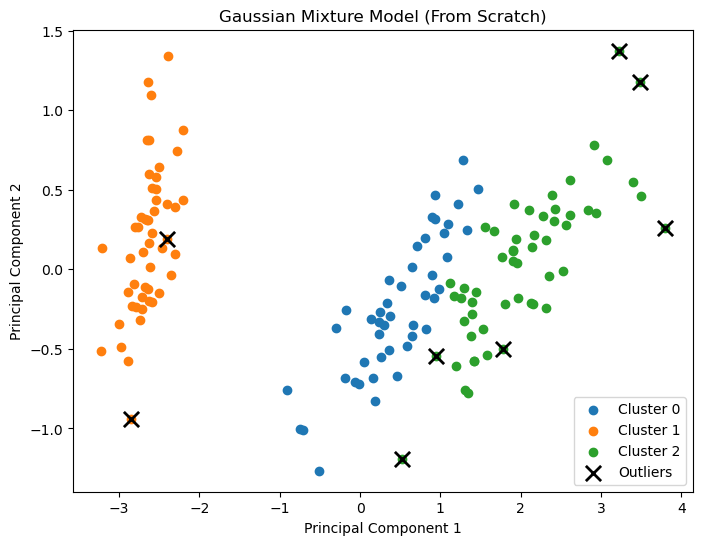


Mixing Coefficients:

[0.29931899 0.33333333 0.36734768]

Means:

[[5.91507094 2.77785354 4.20176462 1.29704913]
 [5.006      3.428      1.462      0.246     ]
 [6.54468168 2.94871159 5.47981885 1.9847734 ]]

Covariance Matrices:


Component 0
[[0.27532298 0.09691825 0.18469313 0.05440689]
 [0.09691825 0.09264108 0.09113411 0.04299642]
 [0.18469313 0.09113411 0.20071268 0.06101355]
 [0.05440689 0.04299642 0.06101355 0.03201496]]

Component 1
[[0.121765 0.097232 0.016028 0.010124]
 [0.097232 0.140817 0.011464 0.009112]
 [0.016028 0.011464 0.029557 0.005948]
 [0.010124 0.009112 0.005948 0.010885]]

Component 2
[[0.38704916 0.09220749 0.30276553 0.06159108]
 [0.09220749 0.11034237 0.08425757 0.05599347]
 [0.30276553 0.08425757 0.32765651 0.07440921]
 [0.06159108 0.05599347 0.07440921 0.08573354]]


In [5]:
# Visualization using PCA
pca = PCA(n_components=2)

X2 = pca.fit_transform(X)

plt.figure(figsize=(8,6))

for k in range(3):

    plt.scatter(
        X2[clusters==k,0],
        X2[clusters==k,1],
        label=f"Cluster {k}"
    )

plt.scatter(
    X2[outliers,0],
    X2[outliers,1],
    color="black",
    marker="x",
    s=120,
    linewidth=2,
    label="Outliers"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Gaussian Mixture Model (From Scratch)")
plt.legend()
plt.show()


# Print Learned Parameters
print("\nMixing Coefficients:\n")
print(gmm.weights)

print("\nMeans:\n")
print(gmm.means)

print("\nCovariance Matrices:\n")
for i, cov in enumerate(gmm.covariances):
    print(f"\nComponent {i}")
    print(cov)